## 1) Importar bibliotecas

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
import polars as pl
import numpy as np

## 2) Carregar dados

In [2]:
mnist = tf.keras.datasets.mnist

mnist = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### 2.1) Separar dados em treino e teste

In [35]:
(X_train, y_train), (X_test, y_test) = mnist

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### 2.2) Avaliar desbalanceamento

<p>Aqui, por sorte, podemos assumir que os targets de treinamento estão balanceados.</p>

In [ ]:
target_distribution_df = pl.DataFrame(data = {"target": y_train}).group_by("target").agg(
    pl.col("target").len().alias("total"),
).with_columns(
    (pl.col("total")/pl.col("total").sum()).alias("percentage")
).sort(by = "target")

target_distribution_df

target,total,percentage
u8,u32,f64
5,5421,0.09035
4,5842,0.097367
8,5851,0.097517
6,5918,0.098633
0,5923,0.098717
9,5949,0.09915
2,5958,0.0993
3,6131,0.102183
7,6265,0.104417


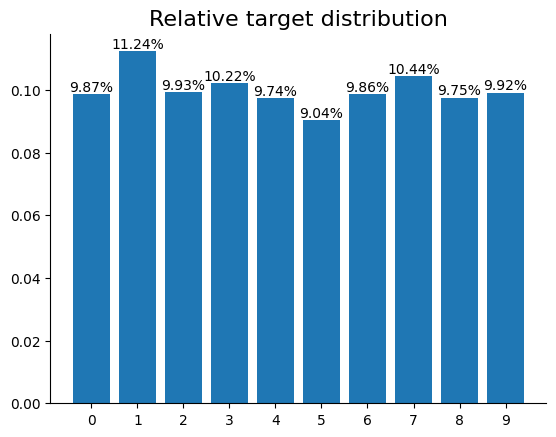

In [72]:
fig, ax = plt.subplots()

bar_plot = ax.bar(
    x = target_distribution_df["target"],
    height = target_distribution_df["percentage"],
)

ax.bar_label(
    container = bar_plot,
    labels = [
        f"{np.round(a = percentage*100, decimals = 2)}%" for percentage in target_distribution_df["percentage"]
    ],
)

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(ticks = np.arange(0,10, 1))
ax.set_title("Relative target distribution", fontsize = 16)

plt.show()

### 2.3) Mostrando imagens

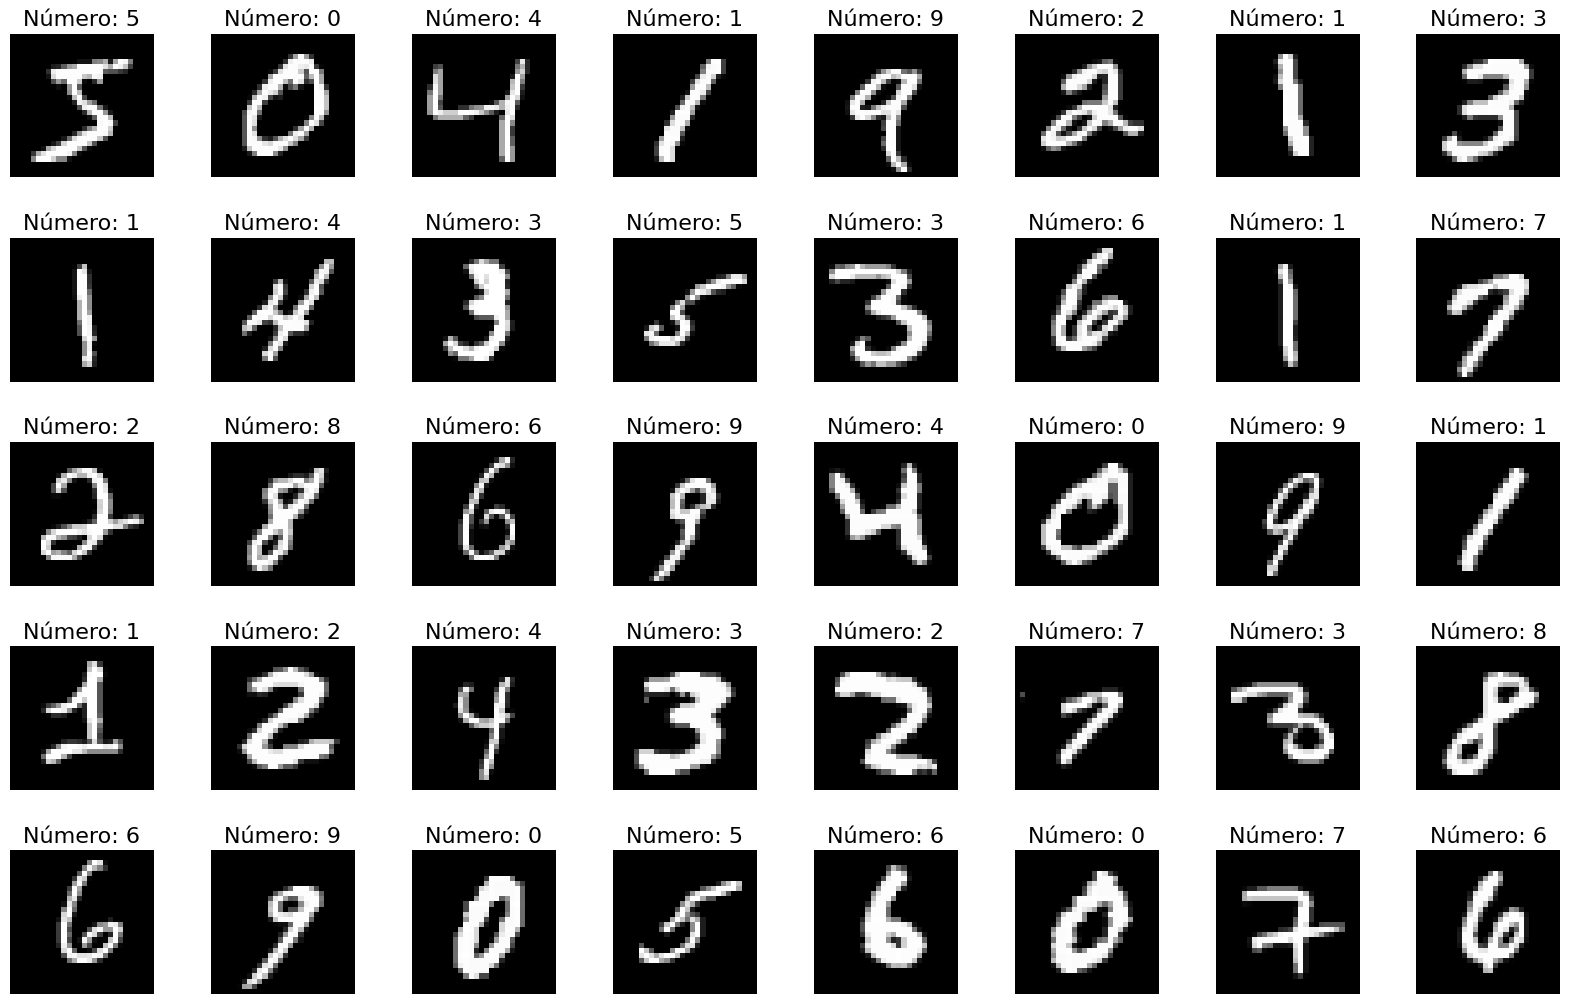

In [93]:
fig, axs = plt.subplots(
    nrows = 5,
    ncols = 8,
    figsize = (20, 12.5),
    gridspec_kw = {
        "hspace": 0.4,
        "wspace": 0.4
    }
)

for i, ax in enumerate(axs.flatten()):
    ax.imshow(X_train[i], cmap = "gray")
    ax.set_title(f"Número: {y_train[i]}", fontsize = 16)
    ax.spines[["top", "left", "bottom", "right"]].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### 2.4) Mostrando números detalhadamente

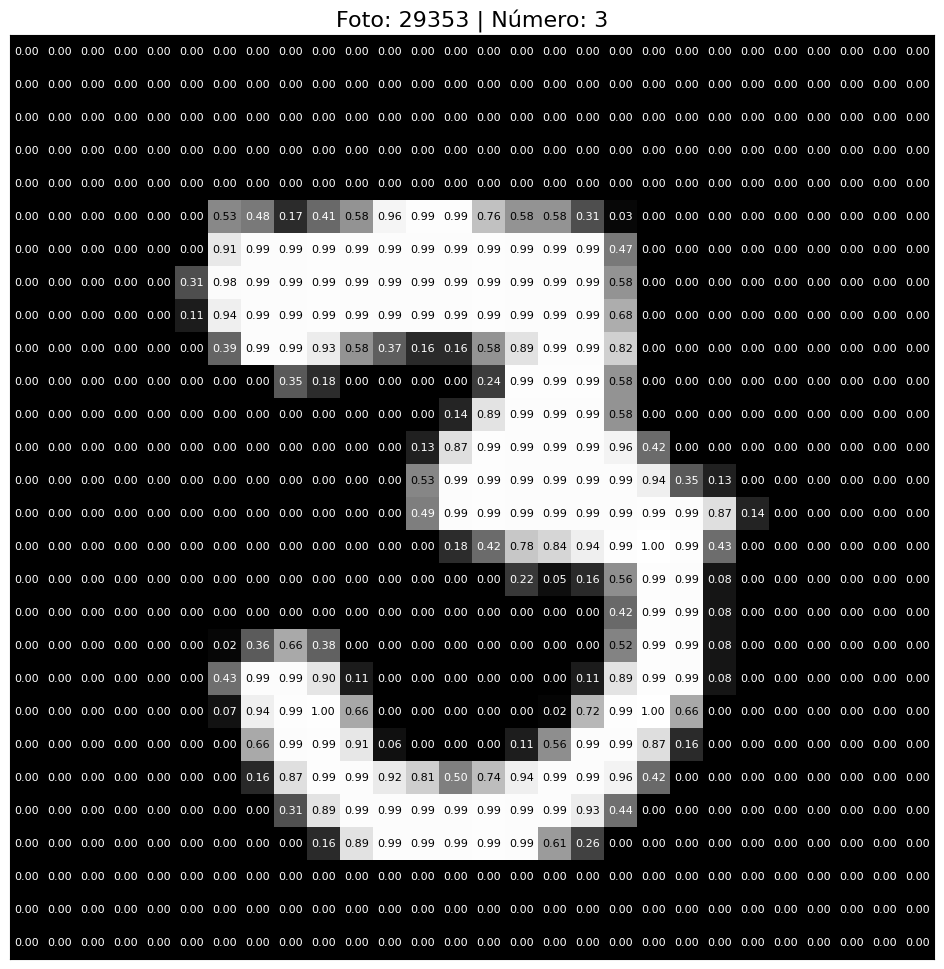

In [133]:
fig, ax = plt.subplots(
    figsize = (12, 12)
)

order = np.random.randint(low = 0, high = len(X_train))
image = X_train[order]/255

ax.imshow(
    X = image,
    cmap = "gray"
)

for y, y_axis in enumerate(image):
    for x, x_axis in enumerate(y_axis):
        value = image[y][x]
        ax.annotate(
            text = f"{value:.2f}",
            xy = (x, y),
            color = "white" if value < 0.5 else "black",
            verticalalignment = "center",
            horizontalalignment = "center",
            fontsize = 8
        )

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Foto: {order} | Número: {y_train[order]}", fontsize = 16)

plt.show()

## 3) Criar modelo

In [128]:
X_test.shape

(10000, 28, 28)

In [129]:
tf.keras.layers.Input?

Signature:
tf.keras.layers.Input(
    shape=None,
    batch_size=None,
    dtype=None,
    sparse=None,
    ragged=None,
    batch_shape=None,
    name=None,
    tensor=None,
    optional=False,
)
Docstring:
Used to instantiate a Keras tensor.

A Keras tensor is a symbolic tensor-like object, which we augment with
certain attributes that allow us to build a Keras model just by knowing the
inputs and outputs of the model.

For instance, if `a`, `b` and `c` are Keras tensors,
it becomes possible to do:
`model = Model(input=[a, b], output=c)`

Args:
    shape: A shape tuple (tuple of integers or `None` objects),
        not including the batch size.
        For instance, `shape=(32,)` indicates that the expected input
        will be batches of 32-dimensional vectors. Elements of this tuple
        can be `None`; `None` elements represent dimensions where the shape
        is not known and may vary (e.g. sequence length).
    batch_size: Optional static batch size (integer).
    dtype: Th

In [130]:
tf.keras.layers.InputLayer?

Init signature:
tf.keras.layers.InputLayer(
    shape=None,
    batch_size=None,
    dtype=None,
    sparse=None,
    ragged=None,
    batch_shape=None,
    input_tensor=None,
    optional=False,
    name=None,
    **kwargs,
)
Docstring:     
This is the class from which all layers inherit.

A layer is a callable object that takes as input one or more tensors and
that outputs one or more tensors. It involves *computation*, defined
in the `call()` method, and a *state* (weight variables). State can be
created:

* in `__init__()`, for instance via `self.add_weight()`;
* in the optional `build()` method, which is invoked by the first
  `__call__()` to the layer, and supplies the shape(s) of the input(s),
  which may not have been known at initialization time.

Layers are recursively composable: If you assign a Layer instance as an
attribute of another Layer, the outer layer will start tracking the weights
created by the inner layer. Nested layers should be instantiated in the
`__init__()`